##Milestone 2&3

Describe your dataset (1.5pts):

I used the **[NASA Nearest Earth Objects Dataset](https://www.kaggle.com/datasets/sameepvani/nasa-nearest-earth-objects/data
)**, which contains observations of near-Earth asteroids collected by NASA. The dataset includes over 90,000 instances, making it sufficiently large yet still computationally manageable.

- What are the primary features of the dataset?

**“id”**: Unique Identifier for each Asteroid

**“name”**: Name given by NASA

**“est_diameter_min”**: Minimum Estimated Diameter in Kilometres

**“est_diameter_max”**: Maximum Estimated Diameter in Kilometres

**“relative_velocity”**: Velocity relative to Earth

**“miss_distance”**: Distance in Kilometres missed

**“absolute_magnitude”**: Intrinsic brightness

**“hazardous”**: Whether the asteroid is potentially

*Some identifier fields are present but will not be usede in modeling*

---

- What task(s) can you accomplish with this data?
1. Classification: Predict whether an asteroid is hazardous.

2. Probabilistic inference: Estimate *P(Hazardous∣features)*.

3. Sequential modeling (for HMM): Model how latent risk states evolve across ordered observations.


---



- Is the data relevant to
probabilistic modeling? Explain how.


Yes. This dataset is highly relevant to probabilistic modeling because:
* The relationship between asteroid features (size, velocity, distance) and hazard status is uncertain and non-deterministic
* Observations are subject to measurement noise and incomplete information

* Different combinations of features may lead to different risk levels


---


- How will you preprocess your data, if any is needed?

A couple things to consider:
- How big is the dataset? Is it reasonably processable?
- Where is the data from, and is it reliable?
- Is your data categorical or continuous, or both?

---
Topics to cover:

1. Motivation and Problem Statement (1pts):

The goal of this project is to model the risk associated with near-Earth asteroids based on observable physical properties.

Uncertainty modeling is essential because asteroid hazard cannot be determined deterministically. For example, an asteroid with high velocity may not be hazardous if its distance is large. Therefore, probabilistic models are necessary to represent these uncertain relationships.

Non-probabilistic approaches (e.g., rule-based systems) cannot effectively capture uncertainty or provide probabilistic predictions. In contrast, probabilistic models allow us to infer risk under incomplete or noisy observations.



---


2. Explain your agent in terms of PEAS. (0.5pts)

**Performance Measure**
Accuracy of hazard prediction;
Likelihood of observation sequences;
Quality of inferred hidden states

**Environment** Near-Earth space with varying asteroid properties
Uncertain observational conditions

**Actuators**
Output predicted hazard level or probability

**Sensors**
Observed asteroid features (velocity, distance, size, magnitude)

---




3. Methodology (1.5pts):
3. Methodology (1.5 pts)

Models

We use two probabilistic models:

- A Bayesian Network (BN) to model conditional dependencies between asteroid features and hazard labels
- A Hidden Markov Model (HMM) to model latent risk evolution across asteroids

Bayesian Network (BN)

We model dependencies such as:

- Diameter -> Hazard
- Velocity -> Hazard
- Distance -> Hazard
- Magnitude -> Hazard

This assumes that asteroid hazard depends on physical characteristics.

The joint probability distribution is:

P(H, D, V, S, M)
= P(H | D, V, S, M) * P(D) * P(V) * P(S) * P(M)

Where:
- H = Hazard
- D = Diameter
- V = Velocity
- S = Distance
- M = Magnitude

CPT Estimation

Conditional Probability Tables (CPTs) are estimated using Maximum Likelihood Estimation (MLE):

P(X | Pa(X)) = N(X, Pa(X)) / N(Pa(X))

Where:
- N(X, Pa(X)) is the count of occurrences
- Pa(X) are parent nodes

Example:

P(Hazard = yes | Diameter = large)
= N(H = yes, D = large) / N(D = large)

Hidden Markov Model (HMM)

We define latent states representing risk levels:
- Low Risk
- High Risk

Observations are discretized asteroid features:
- Velocity category
- Distance category
- Diameter category
- Magnitude category

The HMM structure is:

Z_t -> Z_(t+1)
Z_t -> O_t

Where:
- Z_t = hidden risk state
- O_t = observed asteroid features

HMM Parameters

Initial distribution:

pi_i = P(Z_1 = i)

Estimated as:

pi_i = gamma_1(i)

Transition matrix:

A_ij = P(Z_(t+1) = j | Z_t = i)

Estimated as:

A_ij = sum over t of xi_t(i,j) / sum over t of gamma_t(i)

Emission matrix:

B_j(k) = P(O_t = k | Z_t = j)

Estimated as:

B_j(k) = sum over t of [gamma_t(j) * I(O_t = k)] / sum over t of gamma_t(j)

Where:
- gamma_t(j) = posterior probability of state j at time t
- xi_t(i,j) = posterior probability of transition from state i to state j at time t
- I(O_t = k) = indicator function, equal to 1 if O_t = k and 0 otherwise

Learning Algorithm

We use Baum-Welch (EM Algorithm).

E-step:
- Compute forward probabilities
- Compute backward probabilities
- Compute gamma
- Compute xi

M-step:
- Update initial distribution pi
- Update transition matrix A
- Update emission matrix B

Approximations / Assumptions

To simplify the model, we assume:
- Observations are conditionally independent given hidden states
- Continuous variables are discretized into bins
- Asteroids are arranged into pseudo sequences
- Two hidden states sufficiently represent risk levels

Model Evaluation

We evaluate our models using:

1. Classification Accuracy

Accuracy = Correct Predictions / Total Samples

We assign each hidden state to a risk label and compute prediction accuracy.

2. Log-Likelihood

Log-likelihood measures model fit:

log P(O | theta)

Higher log-likelihood indicates better model fit.

3. Baseline Comparison

We compare performance with:
- Majority class baseline
- Bayesian Network model


##Milestone4

In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample

In [46]:
df_raw = pd.read_csv("/nasa.csv")

print("Original raw shape:", df_raw.shape)
print(df_raw.head())
print(df_raw.columns.tolist())

Original raw shape: (90836, 10)
        id                 name  est_diameter_min  est_diameter_max  \
0  2162635  162635 (2000 SS164)          1.198271          2.679415   
1  2277475    277475 (2005 WK4)          0.265800          0.594347   
2  2512244   512244 (2015 YE18)          0.722030          1.614507   
3  3596030          (2012 BV13)          0.096506          0.215794   
4  3667127          (2014 GE35)          0.255009          0.570217   

   relative_velocity  miss_distance orbiting_body  sentry_object  \
0       13569.249224   5.483974e+07         Earth          False   
1       73588.726663   6.143813e+07         Earth          False   
2      114258.692129   4.979872e+07         Earth          False   
3       24764.303138   2.543497e+07         Earth          False   
4       42737.733765   4.627557e+07         Earth          False   

   absolute_magnitude  hazardous  
0               16.73      False  
1               20.00       True  
2               17.83      

In [47]:
cols = [
    "est_diameter_max",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude",
    "hazardous"
]
df = df_raw[cols].copy()

print("Shape after selecting columns:", df.shape)
print(df.isna().sum())
print(df.head())

Shape after selecting columns: (90836, 5)
est_diameter_max      0
relative_velocity     0
miss_distance         0
absolute_magnitude    0
hazardous             0
dtype: int64
   est_diameter_max  relative_velocity  miss_distance  absolute_magnitude  \
0          2.679415       13569.249224   5.483974e+07               16.73   
1          0.594347       73588.726663   6.143813e+07               20.00   
2          1.614507      114258.692129   4.979872e+07               17.83   
3          0.215794       24764.303138   2.543497e+07               22.20   
4          0.570217       42737.733765   4.627557e+07               20.09   

   hazardous  
0      False  
1       True  
2      False  
3      False  
4       True  


In [48]:
for col in ["est_diameter_max", "relative_velocity", "miss_distance"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)
print(df.isna().sum())

est_diameter_max      float64
relative_velocity     float64
miss_distance         float64
absolute_magnitude    float64
hazardous                bool
dtype: object
est_diameter_max      0
relative_velocity     0
miss_distance         0
absolute_magnitude    0
hazardous             0
dtype: int64


In [49]:
print(df["hazardous"].value_counts(dropna=False))
print(df["hazardous"].unique()[:20])

hazardous
False    81996
True      8840
Name: count, dtype: int64
[False  True]


In [50]:
df["hazardous"] = df["hazardous"].astype(str).str.strip().str.lower()

print("After lower():")
print(df["hazardous"].value_counts(dropna=False))

df = df[df["hazardous"].isin(["true", "false"])].copy()

df["hazardous"] = df["hazardous"].map({
    "true": "hazardous",
    "false": "non_hazardous"
})

print("\nAfter mapping:")
print(df["hazardous"].value_counts(dropna=False))
print("Shape now:", df.shape)

After lower():
hazardous
false    81996
true      8840
Name: count, dtype: int64

After mapping:
hazardous
non_hazardous    81996
hazardous         8840
Name: count, dtype: int64
Shape now: (90836, 5)


In [51]:
df = df.dropna(subset=["est_diameter_max", "relative_velocity", "miss_distance", "hazardous"]).reset_index(drop=True)

print("Shape after dropna:", df.shape)
print(df.head())

Shape after dropna: (90836, 5)
   est_diameter_max  relative_velocity  miss_distance  absolute_magnitude  \
0          2.679415       13569.249224   5.483974e+07               16.73   
1          0.594347       73588.726663   6.143813e+07               20.00   
2          1.614507      114258.692129   4.979872e+07               17.83   
3          0.215794       24764.303138   2.543497e+07               22.20   
4          0.570217       42737.733765   4.627557e+07               20.09   

       hazardous  
0  non_hazardous  
1      hazardous  
2  non_hazardous  
3  non_hazardous  
4      hazardous  


In [52]:
def bin_by_quantiles(series, labels):
    qs = series.quantile(np.linspace(0, 1, len(labels) + 1)).values
    qs = np.unique(qs)
    use_labels = labels[:len(qs) - 1]
    return pd.cut(
        series,
        bins=qs,
        labels=use_labels,
        include_lowest=True,
        duplicates="drop"
    )

In [53]:
df["diameter_bin"] = bin_by_quantiles(df["est_diameter_max"], ["small", "medium", "large"])
df["velocity_bin"] = bin_by_quantiles(df["relative_velocity"], ["low", "medium", "high"])
df["distance_bin"] = bin_by_quantiles(df["miss_distance"], ["near", "medium", "far"])
df["magnitude_bin"] = bin_by_quantiles(df["absolute_magnitude"], ["low", "medium", "high"])

print(df[[
    "est_diameter_max", "diameter_bin",
    "relative_velocity", "velocity_bin",
    "miss_distance", "distance_bin",
    "absolute_magnitude", "magnitude_bin"
]].head())

   est_diameter_max diameter_bin  relative_velocity velocity_bin  \
0          2.679415        large       13569.249224          low   
1          0.594347        large       73588.726663         high   
2          1.614507        large      114258.692129         high   
3          0.215794       medium       24764.303138          low   
4          0.570217        large       42737.733765       medium   

   miss_distance distance_bin  absolute_magnitude magnitude_bin  
0   5.483974e+07          far               16.73           low  
1   6.143813e+07          far               20.00           low  
2   4.979872e+07       medium               17.83           low  
3   2.543497e+07       medium               22.20        medium  
4   4.627557e+07       medium               20.09           low  


In [54]:
bn_df = df[[
    "hazardous",
    "diameter_bin",
    "velocity_bin",
    "distance_bin",
    "magnitude_bin"
]].copy()

print("Before final dropna:", bn_df.shape)
print(bn_df.isna().sum())

bn_df = bn_df.dropna().reset_index(drop=True)

print("\nAfter final dropna:", bn_df.shape)
print(bn_df.head())

for col in bn_df.columns:
    print(f"\n{col}")
    print(bn_df[col].value_counts(dropna=False))

Before final dropna: (90836, 5)
hazardous        0
diameter_bin     0
velocity_bin     0
distance_bin     0
magnitude_bin    0
dtype: int64

After final dropna: (90836, 5)
       hazardous diameter_bin velocity_bin distance_bin magnitude_bin
0  non_hazardous        large          low          far           low
1      hazardous        large         high          far           low
2  non_hazardous        large         high       medium           low
3  non_hazardous       medium          low       medium        medium
4      hazardous        large       medium       medium           low

hazardous
hazardous
non_hazardous    81996
hazardous         8840
Name: count, dtype: int64

diameter_bin
diameter_bin
small     31019
large     30261
medium    29556
Name: count, dtype: int64

velocity_bin
velocity_bin
low       30279
high      30279
medium    30278
Name: count, dtype: int64

distance_bin
distance_bin
near      30279
far       30279
medium    30278
Name: count, dtype: int64

magnitude_b

In [55]:
train_df, test_df = train_test_split(
    bn_df,
    test_size=0.2,
    random_state=42,
    stratify=bn_df["hazardous"]
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain class distribution:")
print(train_df["hazardous"].value_counts(normalize=True))

print("\nTest class distribution:")
print(test_df["hazardous"].value_counts(normalize=True))

Train shape: (72668, 5)
Test shape: (18168, 5)

Train class distribution:
hazardous
non_hazardous    0.902681
hazardous        0.097319
Name: proportion, dtype: float64

Test class distribution:
hazardous
non_hazardous    0.902686
hazardous        0.097314
Name: proportion, dtype: float64


In [56]:
haz = train_df[train_df["hazardous"] == "hazardous"]
non = train_df[train_df["hazardous"] == "non_hazardous"]

print("Original training counts:")
print(train_df["hazardous"].value_counts())

non_down = resample(
    non,
    replace=False,
    n_samples=len(haz),
    random_state=42
)

balanced_train = pd.concat([haz, non_down]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced training counts:")
print(balanced_train["hazardous"].value_counts())
print("Balanced training shape:", balanced_train.shape)

Original training counts:
hazardous
non_hazardous    65596
hazardous         7072
Name: count, dtype: int64

Balanced training counts:
hazardous
non_hazardous    7072
hazardous        7072
Name: count, dtype: int64
Balanced training shape: (14144, 5)


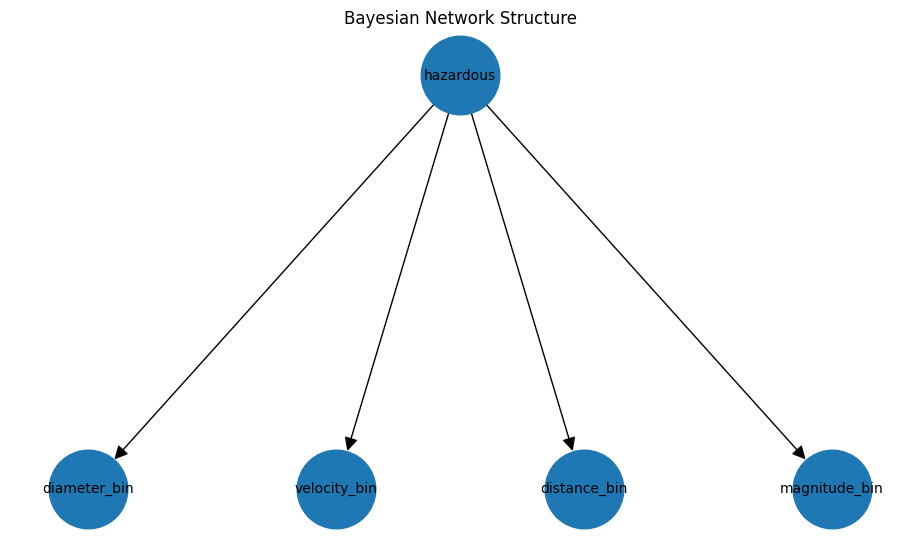

In [57]:
G = nx.DiGraph()

G.add_edges_from([
    ("hazardous", "diameter_bin"),
    ("hazardous", "velocity_bin"),
    ("hazardous", "distance_bin"),
    ("hazardous", "magnitude_bin"),
])

plt.figure(figsize=(9, 5))
pos = {
    "hazardous": (0, 1),
    "diameter_bin": (-1.5, 0),
    "velocity_bin": (-0.5, 0),
    "distance_bin": (0.5, 0),
    "magnitude_bin": (1.5, 0),
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3200,
    font_size=10,
    arrowsize=20
)
plt.title("Bayesian Network Structure")
plt.show()

In [58]:
prior = balanced_train["hazardous"].value_counts(normalize=True)

print("Prior:")
print(prior)

cpt_diameter = pd.crosstab(
    balanced_train["diameter_bin"],
    balanced_train["hazardous"],
    normalize="columns"
)

cpt_velocity = pd.crosstab(
    balanced_train["velocity_bin"],
    balanced_train["hazardous"],
    normalize="columns"
)

cpt_distance = pd.crosstab(
    balanced_train["distance_bin"],
    balanced_train["hazardous"],
    normalize="columns"
)

cpt_magnitude = pd.crosstab(
    balanced_train["magnitude_bin"],
    balanced_train["hazardous"],
    normalize="columns"
)

print("\nCPT diameter:")
print(cpt_diameter)

print("\nCPT velocity:")
print(cpt_velocity)

print("\nCPT distance:")
print(cpt_distance)

print("\nCPT magnitude:")
print(cpt_magnitude)

Prior:
hazardous
non_hazardous    0.5
hazardous        0.5
Name: proportion, dtype: float64

CPT diameter:
hazardous     hazardous  non_hazardous
diameter_bin                          
small          0.000000       0.382777
medium         0.001414       0.357466
large          0.998586       0.259757

CPT velocity:
hazardous     hazardous  non_hazardous
velocity_bin                          
low            0.129949       0.355911
medium         0.326782       0.325933
high           0.543269       0.318156

CPT distance:
hazardous     hazardous  non_hazardous
distance_bin                          
near           0.284502       0.337245
medium         0.347002       0.331448
far            0.368495       0.331307

CPT magnitude:
hazardous      hazardous  non_hazardous
magnitude_bin                          
low             0.998586       0.259898
medium          0.001414       0.369627
high            0.000000       0.370475


In [59]:
def predict(row):
    probs = {}

    for h in prior.index:
        p = prior[h]

        p *= cpt_diameter.loc[row["diameter_bin"], h]
        p *= cpt_velocity.loc[row["velocity_bin"], h]
        p *= cpt_distance.loc[row["distance_bin"], h]
        p *= cpt_magnitude.loc[row["magnitude_bin"], h]

        probs[h] = p

    return max(probs, key=probs.get)

In [60]:
y_pred = test_df.apply(predict, axis=1)

accuracy = accuracy_score(test_df["hazardous"], y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(test_df["hazardous"], y_pred))

Accuracy: 0.7664024658740642

Classification Report:
               precision    recall  f1-score   support

    hazardous       0.29      1.00      0.45      1768
non_hazardous       1.00      0.74      0.85     16400

     accuracy                           0.77     18168
    macro avg       0.65      0.87      0.65     18168
 weighted avg       0.93      0.77      0.81     18168



In [61]:
majority_class = train_df["hazardous"].mode()[0]
baseline_pred = [majority_class] * len(test_df)

baseline_acc = accuracy_score(test_df["hazardous"], baseline_pred)

print("Baseline majority-class accuracy:", baseline_acc)
print("Balanced BN accuracy:", accuracy)

Baseline majority-class accuracy: 0.9026860413914575
Balanced BN accuracy: 0.7664024658740642


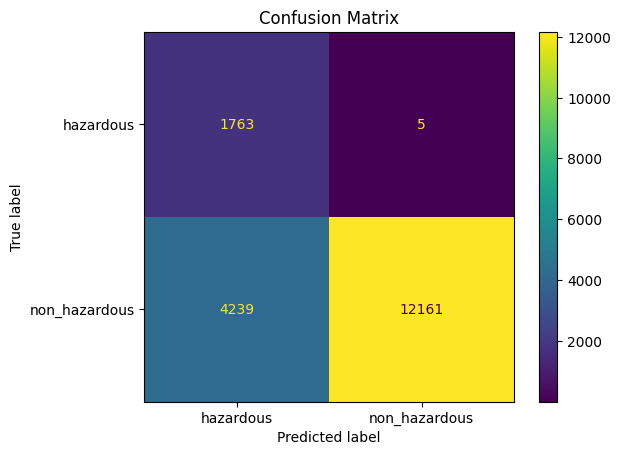

In [62]:
ConfusionMatrixDisplay.from_predictions(
    test_df["hazardous"],
    y_pred
)

plt.title("Confusion Matrix")
plt.show()

In [63]:
def predict_with_scores(row):
    probs = {}

    for h in prior.index:
        p = prior[h]
        p *= cpt_diameter.loc[row["diameter_bin"], h]
        p *= cpt_velocity.loc[row["velocity_bin"], h]
        p *= cpt_distance.loc[row["distance_bin"], h]
        p *= cpt_magnitude.loc[row["magnitude_bin"], h]
        probs[h] = p

    total = sum(probs.values())
    if total > 0:
        probs = {k: v / total for k, v in probs.items()}

    pred = max(probs, key=probs.get)
    return pred, probs

example_results = test_df.head(10).copy()

preds = []
haz_probs = []

for _, row in example_results.iterrows():
    pred, probs = predict_with_scores(row)
    preds.append(pred)
    haz_probs.append(probs.get("hazardous", 0.0))

example_results["predicted_class"] = preds
example_results["P(hazardous | evidence)"] = haz_probs

print(example_results)

           hazardous diameter_bin velocity_bin distance_bin magnitude_bin  \
34066  non_hazardous        small          low         near          high   
6656       hazardous        large          low          far           low   
17138  non_hazardous        small       medium          far          high   
81478  non_hazardous       medium          low         near        medium   
82373  non_hazardous        small          low       medium          high   
41775  non_hazardous        large          low       medium           low   
87335  non_hazardous       medium         high         near        medium   
18181  non_hazardous       medium       medium         near        medium   
9069   non_hazardous       medium         high         near        medium   
84097  non_hazardous       medium         high       medium        medium   

      predicted_class  P(hazardous | evidence)  
34066   non_hazardous                 0.000000  
6656        hazardous                 0.857110  
17138

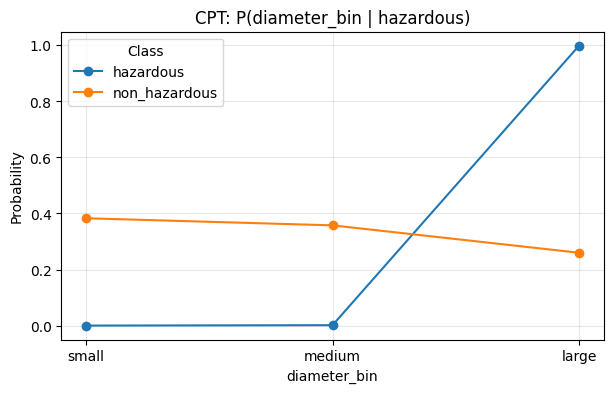

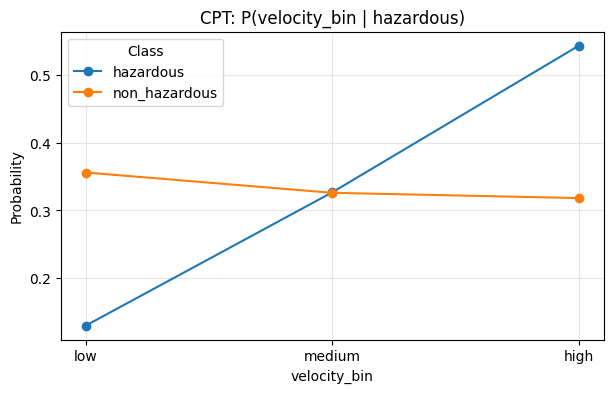

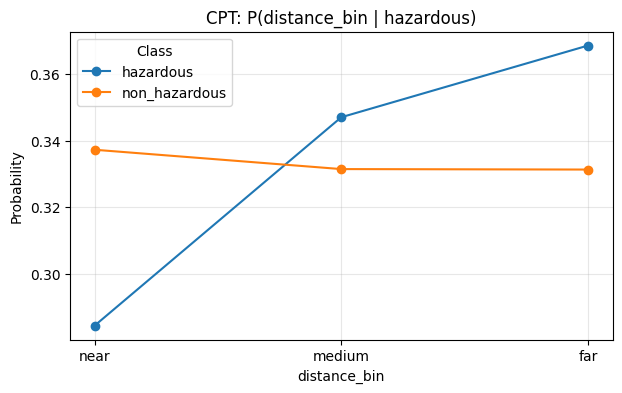

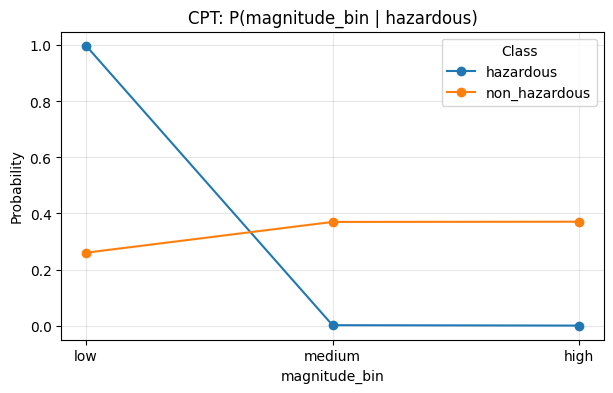

In [64]:
def plot_cpt(cpt, feature_name):
    cpt_plot = cpt.copy()

    plt.figure(figsize=(7, 4))
    for col in cpt_plot.columns:
        plt.plot(cpt_plot.index.astype(str), cpt_plot[col], marker="o", label=col)

    plt.title(f"CPT: P({feature_name} | hazardous)")
    plt.xlabel(feature_name)
    plt.ylabel("Probability")
    plt.legend(title="Class")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_cpt(cpt_diameter, "diameter_bin")
plot_cpt(cpt_velocity, "velocity_bin")
plot_cpt(cpt_distance, "distance_bin")
plot_cpt(cpt_magnitude, "magnitude_bin")

##Milestone 5&6

In [65]:
print(df.columns)
print(df.head())

Index(['est_diameter_max', 'relative_velocity', 'miss_distance',
       'absolute_magnitude', 'hazardous', 'diameter_bin', 'velocity_bin',
       'distance_bin', 'magnitude_bin'],
      dtype='object')
   est_diameter_max  relative_velocity  miss_distance  absolute_magnitude  \
0          2.679415       13569.249224   5.483974e+07               16.73   
1          0.594347       73588.726663   6.143813e+07               20.00   
2          1.614507      114258.692129   4.979872e+07               17.83   
3          0.215794       24764.303138   2.543497e+07               22.20   
4          0.570217       42737.733765   4.627557e+07               20.09   

       hazardous diameter_bin velocity_bin distance_bin magnitude_bin  
0  non_hazardous        large          low          far           low  
1      hazardous        large         high          far           low  
2  non_hazardous        large         high       medium           low  
3  non_hazardous       medium          low     

In [86]:
hmm_df=balanced_train.copy()

In [143]:
import pandas as pd
import numpy as np

hmm_df = balanced_train[[
    "diameter_bin",
    "velocity_bin",
    "distance_bin",
    "magnitude_bin",
    "hazardous"
]].dropna().copy()

distance_order = {"near": 0, "medium": 1, "far": 2}
diameter_order = {"small": 0, "medium": 1, "large": 2}
velocity_order = {"low": 0, "medium": 1, "high": 2}
magnitude_order = {"low": 0, "medium": 1, "high": 2}

hmm_df["distance_ord"] = hmm_df["distance_bin"].map(distance_order)
hmm_df["diameter_ord"] = hmm_df["diameter_bin"].map(diameter_order)
hmm_df["velocity_ord"] = hmm_df["velocity_bin"].map(velocity_order)
hmm_df["magnitude_ord"] = hmm_df["magnitude_bin"].map(magnitude_order)

hmm_df = hmm_df.sort_values(
    ["distance_ord", "diameter_ord", "velocity_ord", "magnitude_ord"]
).reset_index(drop=True)

In [144]:
hmm_df["obs_symbol"] = (
    hmm_df["diameter_bin"].astype(str) + "_" +
    hmm_df["velocity_bin"].astype(str) + "_" +
    hmm_df["distance_bin"].astype(str) + "_" +
    hmm_df["magnitude_bin"].astype(str)
)

print(hmm_df[["obs_symbol", "hazardous"]].head())
print("Unique observation symbols:", hmm_df["obs_symbol"].nunique())
print(hmm_df["obs_symbol"].value_counts().head(10))
print(hmm_df["hazardous"].value_counts(normalize=True))

              obs_symbol      hazardous
0  small_low_near_medium  non_hazardous
1  small_low_near_medium  non_hazardous
2  small_low_near_medium  non_hazardous
3  small_low_near_medium  non_hazardous
4  small_low_near_medium  non_hazardous
Unique observation symbols: 37
obs_symbol
large_high_far_low         2259
large_high_medium_low      1588
large_medium_medium_low    1084
large_medium_near_low       931
large_high_near_low         931
large_medium_far_low        830
small_low_near_high         700
large_low_medium_low        508
large_low_far_low           397
medium_low_near_medium      395
Name: count, dtype: int64
hazardous
non_hazardous    0.5
hazardous        0.5
Name: proportion, dtype: float64


In [146]:
obs_values = sorted(hmm_df["obs_symbol"].unique())
obs_to_idx = {obs: i for i, obs in enumerate(obs_values)}
idx_to_obs = {i: obs for obs, i in obs_to_idx.items()}

observations = hmm_df["obs_symbol"].map(obs_to_idx).to_numpy()

print("Observation space size M =", len(obs_values))
print("First 20 encoded observations:", observations[:20])

Observation space size M = 37
First 20 encoded observations: [30 30 30 30 30 30 30 30 30 30 30 30 30 30 30 30 30 30 30 30]


In [147]:
K = 2                      # hidden states
M = len(obs_values)        # observation symbols

np.random.seed(42)

# initial distribution
pi = np.random.rand(K)
pi = pi / pi.sum()

# transition matrix
A = np.random.rand(K, K)
A = A / A.sum(axis=1, keepdims=True)

# emission matrix
B = np.random.rand(K, M)
B = B / B.sum(axis=1, keepdims=True)

print("pi shape:", pi.shape)
print("A shape:", A.shape)
print("B shape:", B.shape)
print("Initial pi:", pi)

pi shape: (2,)
A shape: (2, 2)
B shape: (2, 37)
Initial pi: [0.28261752 0.71738248]


In [148]:
def forward_scaled(obs_seq, pi, A, B):
    T = len(obs_seq)
    K = len(pi)

    alpha = np.zeros((T, K))
    c = np.zeros(T)

    # init
    alpha[0] = pi * B[:, obs_seq[0]]
    c[0] = alpha[0].sum()
    if c[0] == 0:
        c[0] = 1e-12
    alpha[0] /= c[0]

    # recursion
    for t in range(1, T):
        for j in range(K):
            alpha[t, j] = B[j, obs_seq[t]] * np.sum(alpha[t-1] * A[:, j])
        c[t] = alpha[t].sum()
        if c[t] == 0:
            c[t] = 1e-12
        alpha[t] /= c[t]

    log_likelihood = np.sum(np.log(c + 1e-12))
    return alpha, c, log_likelihood


def backward_scaled(obs_seq, A, B, c):
    T = len(obs_seq)
    K = A.shape[0]

    beta = np.zeros((T, K))
    beta[-1] = 1.0

    for t in range(T - 2, -1, -1):
        for i in range(K):
            beta[t, i] = np.sum(A[i, :] * B[:, obs_seq[t+1]] * beta[t+1, :])
        beta[t] /= c[t+1]

    return beta

In [149]:
def baum_welch(obs_seq, K, M, n_iter=20, tol=1e-4, random_state=42):
    np.random.seed(random_state)

    # initialize
    pi = np.random.rand(K)
    pi = pi / pi.sum()

    A = np.random.rand(K, K)
    A = A / A.sum(axis=1, keepdims=True)

    B = np.random.rand(K, M)
    B = B / B.sum(axis=1, keepdims=True)

    prev_loglik = None
    loglik_history = []

    T = len(obs_seq)

    for iteration in range(n_iter):
        alpha, c, loglik = forward_scaled(obs_seq, pi, A, B)
        beta = backward_scaled(obs_seq, A, B, c)

        # gamma
        gamma = alpha * beta
        gamma = gamma / gamma.sum(axis=1, keepdims=True)

        # xi
        xi = np.zeros((T - 1, K, K))
        for t in range(T - 1):
            denom = np.sum(
                alpha[t, :, None] * A * B[:, obs_seq[t+1]][None, :] * beta[t+1, :][None, :]
            )
            if denom == 0:
                denom = 1e-12
            xi[t] = (
                alpha[t, :, None] * A * B[:, obs_seq[t+1]][None, :] * beta[t+1, :][None, :]
            ) / denom

        # M-step
        pi = gamma[0]

        A = xi.sum(axis=0)
        A = A / A.sum(axis=1, keepdims=True)

        B = np.zeros((K, M))
        for k in range(K):
            for m in range(M):
                B[k, m] = gamma[obs_seq == m, k].sum()
        B = B / B.sum(axis=1, keepdims=True)

        loglik_history.append(loglik)

        print(f"Iteration {iteration+1:02d} | log-likelihood = {loglik:.4f}")

        if prev_loglik is not None and abs(loglik - prev_loglik) < tol:
            print("Converged.")
            break
        prev_loglik = loglik

    return pi, A, B, loglik_history

In [150]:
pi_hat, A_hat, B_hat, loglik_history = baum_welch(
    observations,
    K=K,
    M=M,
    n_iter=20,
    tol=1e-4,
    random_state=42
)

print("\nEstimated pi:")
print(pi_hat)

print("\nEstimated A:")
print(A_hat)

print("\nEstimated B shape:")
print(B_hat.shape)

Iteration 01 | log-likelihood = -50755.7773
Iteration 02 | log-likelihood = -39933.6232
Iteration 03 | log-likelihood = -36051.8113
Iteration 04 | log-likelihood = -33226.0523
Iteration 05 | log-likelihood = -32973.0130
Iteration 06 | log-likelihood = -32967.4728
Iteration 07 | log-likelihood = -32967.1922
Iteration 08 | log-likelihood = -32967.0833
Iteration 09 | log-likelihood = -32967.0382
Iteration 10 | log-likelihood = -32967.0203
Iteration 11 | log-likelihood = -32967.0134
Iteration 12 | log-likelihood = -32967.0108
Iteration 13 | log-likelihood = -32967.0098
Iteration 14 | log-likelihood = -32967.0094
Iteration 15 | log-likelihood = -32967.0093
Iteration 16 | log-likelihood = -32967.0093
Converged.

Estimated pi:
[7.60612307e-188 1.00000000e+000]

Estimated A:
[[0.99888143 0.00111857]
 [0.00147614 0.99852386]]

Estimated B shape:
(2, 37)


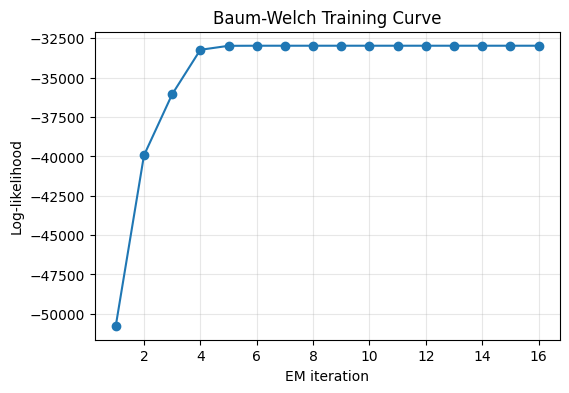

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(loglik_history) + 1), loglik_history, marker="o")
plt.xlabel("EM iteration")
plt.ylabel("Log-likelihood")
plt.title("Baum-Welch Training Curve")
plt.grid(True, alpha=0.3)
plt.show()

In [152]:
alpha_hat, c_hat, final_loglik = forward_scaled(observations, pi_hat, A_hat, B_hat)

print("Final sequence log-likelihood:", final_loglik)

Final sequence log-likelihood: -32967.009231386684


In [155]:
print("pi_hat")
print(pi_hat)
print("\nA_hat")
print(A_hat)


pi_hat
[7.60612307e-188 1.00000000e+000]

A_hat
[[0.99888143 0.00111857]
 [0.00147614 0.99852386]]


In [156]:
def viterbi(obs_seq, pi, A, B):
    T = len(obs_seq)
    K = len(pi)

    delta = np.zeros((T, K))
    psi = np.zeros((T, K), dtype=int)

    delta[0] = np.log(pi + 1e-12) + np.log(B[:, obs_seq[0]] + 1e-12)

    for t in range(1, T):
        for j in range(K):
            scores = delta[t-1] + np.log(A[:, j] + 1e-12)
            psi[t, j] = np.argmax(scores)
            delta[t, j] = np.max(scores) + np.log(B[j, obs_seq[t]] + 1e-12)

    states = np.zeros(T, dtype=int)
    states[-1] = np.argmax(delta[-1])

    for t in range(T - 2, -1, -1):
        states[t] = psi[t + 1, states[t + 1]]

    return states

In [158]:
decoded_states = viterbi(observations, pi_hat, A_hat, B_hat)

print("Decoded states shape:", decoded_states.shape)
print("First 30 decoded states:", decoded_states[:30])

hmm_df["decoded_state"] = decoded_states
print(hmm_df[["obs_symbol", "hazardous", "decoded_state"]].head(20))

Decoded states shape: (14144,)
First 30 decoded states: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
               obs_symbol      hazardous  decoded_state
0   small_low_near_medium  non_hazardous              1
1   small_low_near_medium  non_hazardous              1
2   small_low_near_medium  non_hazardous              1
3   small_low_near_medium  non_hazardous              1
4   small_low_near_medium  non_hazardous              1
5   small_low_near_medium  non_hazardous              1
6   small_low_near_medium  non_hazardous              1
7   small_low_near_medium  non_hazardous              1
8   small_low_near_medium  non_hazardous              1
9   small_low_near_medium  non_hazardous              1
10  small_low_near_medium  non_hazardous              1
11  small_low_near_medium  non_hazardous              1
12  small_low_near_medium  non_hazardous              1
13  small_low_near_medium  non_hazardous              1
14  small_low_near_medium  non_hazardous  

In [159]:
state_vs_label = pd.crosstab(
    hmm_df["decoded_state"],
    hmm_df["hazardous"],
    normalize="index"
)

print(state_vs_label)

hazardous      hazardous  non_hazardous
decoded_state                          
0               0.409396       0.590604
1               0.619547       0.380453


In [162]:
haz_ratio = state_vs_label["hazardous"].sort_values()
state_name_map = {
    haz_ratio.index[0]: "low_risk_state",
    haz_ratio.index[1]: "high_risk_state",
}

hmm_df["decoded_state_name"] = hmm_df["decoded_state"].map(state_name_map)

print(hmm_df[["decoded_state", "decoded_state_name", "hazardous"]].head(20))
print(hmm_df["decoded_state_name"].value_counts())

    decoded_state decoded_state_name      hazardous
0               1    high_risk_state  non_hazardous
1               1    high_risk_state  non_hazardous
2               1    high_risk_state  non_hazardous
3               1    high_risk_state  non_hazardous
4               1    high_risk_state  non_hazardous
5               1    high_risk_state  non_hazardous
6               1    high_risk_state  non_hazardous
7               1    high_risk_state  non_hazardous
8               1    high_risk_state  non_hazardous
9               1    high_risk_state  non_hazardous
10              1    high_risk_state  non_hazardous
11              1    high_risk_state  non_hazardous
12              1    high_risk_state  non_hazardous
13              1    high_risk_state  non_hazardous
14              1    high_risk_state  non_hazardous
15              1    high_risk_state  non_hazardous
16              1    high_risk_state  non_hazardous
17              1    high_risk_state  non_hazardous
18          

In [163]:
comparison = pd.crosstab(
    hmm_df["decoded_state_name"],
    hmm_df["hazardous"],
    margins=True
)

print(comparison)

hazardous           hazardous  non_hazardous    All
decoded_state_name                                 
high_risk_state          3778           2320   6098
low_risk_state           3294           4752   8046
All                      7072           7072  14144


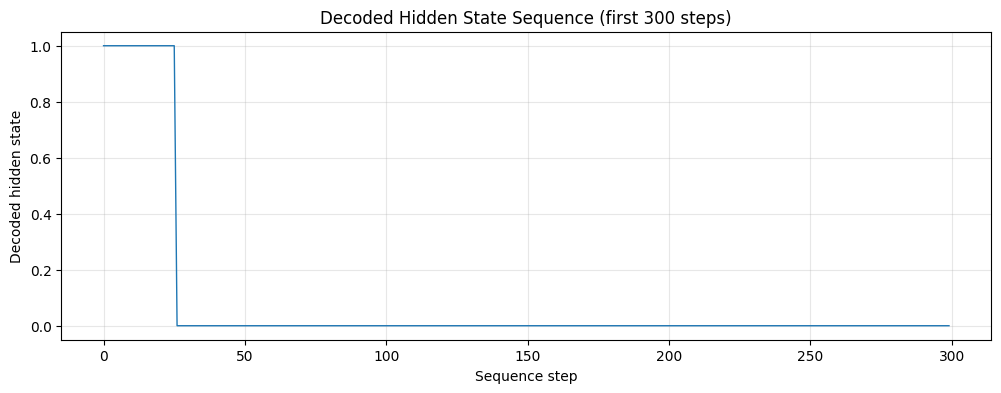

In [164]:
plt.figure(figsize=(12, 4))
plt.plot(hmm_df["decoded_state"].iloc[:300].to_numpy(), linewidth=1)
plt.xlabel("Sequence step")
plt.ylabel("Decoded hidden state")
plt.title("Decoded Hidden State Sequence (first 300 steps)")
plt.grid(True, alpha=0.3)
plt.show()

In [165]:
for col in ["diameter_bin", "velocity_bin", "distance_bin", "magnitude_bin"]:
    table = pd.crosstab(hmm_df["decoded_state_name"], hmm_df[col], normalize="index")
    print(f"\nDistribution of {col} by decoded state:")
    print(table)


Distribution of diameter_bin by decoded state:
diameter_bin           small    medium     large
decoded_state_name                              
high_risk_state     0.101181  0.114628  0.784192
low_risk_state      0.259756  0.228561  0.511683

Distribution of velocity_bin by decoded state:
velocity_bin             low    medium      high
decoded_state_name                              
high_risk_state     0.115612  0.407183  0.477206
low_risk_state      0.339423  0.265101  0.395476

Distribution of distance_bin by decoded state:
distance_bin            near    medium       far
decoded_state_name                              
high_risk_state     0.177107  0.338636  0.484257
low_risk_state      0.412255  0.339672  0.248074

Distribution of magnitude_bin by decoded state:
magnitude_bin            low    medium      high
decoded_state_name                              
high_risk_state     0.784192  0.123155  0.092653
low_risk_state      0.511807  0.232786  0.255406


In [167]:

state_prediction = {
    "low_risk_state": "non_hazardous",
    "high_risk_state": "hazardous"
}

hmm_df["predicted"] = hmm_df["decoded_state_name"].map(state_prediction)

accuracy = (hmm_df["predicted"] == hmm_df["hazardous"]).mean()

print("HMM Accuracy:", accuracy)

HMM Accuracy: 0.6030825791855203


In [168]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    hmm_df["hazardous"],
    hmm_df["predicted"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3778 3294]
 [2320 4752]]
